This dataset comes from cardiotocography, which is essentially a way of recording a baby’s heart rate and the mother’s uterine activity during pregnancy. The goal is to understand whether the baby is doing well. I’ll explain each variable in plain terms so you can build intuition rather than just memorize definitions.

# 3.1 Load Data and Import Libraries
1. Import Libraries: Begin by importing the necessary libraries for data manipulation,
visualization, and machine learning. Common libraries include pandas, numpy, matplotlib,
seaborn, and scikit-learn, among others.
2. Load Data: Load the dataset into a pandas DataFrame. Ensure the data is loaded correctly
and is in a format suitable for preprocessing.

In [110]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Serialization
import joblib
import json

In [111]:
!pip3 install -U ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
df = fetch_ucirepo(id=193)

In [112]:

# data (as pandas dataframes)
X = df.data.features
y = df.data.targets
X.head()
X.info()

# print(y.shape)
y.head()
df_combined = pd.concat([X, y], axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   int64  
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   int64  
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   int64  
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   int64  
 12  Min       2126 non-null   int64  
 13  Max       2126 non-null   int64  
 14  Nmax      2126 non-null   int64  
 15  Nzeros    2126 non-null   int64  
 16  Mode      2126 non-null   int64  
 17  Mean      2126 non-null   int64  
 18  Median    2126 non-null   int64  
 19  Variance  2126 non-null   int64  
 20  Tendency  2126 non-null   int6

In [113]:

df_combined['Tendency'] = df_combined['Tendency'].astype('category')
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LB        2126 non-null   int64   
 1   AC        2126 non-null   float64 
 2   FM        2126 non-null   float64 
 3   UC        2126 non-null   float64 
 4   DL        2126 non-null   float64 
 5   DS        2126 non-null   float64 
 6   DP        2126 non-null   float64 
 7   ASTV      2126 non-null   int64   
 8   MSTV      2126 non-null   float64 
 9   ALTV      2126 non-null   int64   
 10  MLTV      2126 non-null   float64 
 11  Width     2126 non-null   int64   
 12  Min       2126 non-null   int64   
 13  Max       2126 non-null   int64   
 14  Nmax      2126 non-null   int64   
 15  Nzeros    2126 non-null   int64   
 16  Mode      2126 non-null   int64   
 17  Mean      2126 non-null   int64   
 18  Median    2126 non-null   int64   
 19  Variance  2126 non-null   int64   
 20  Tendency

# Explanation of each variables

* The variable **LB** stands for “baseline fetal heart rate.” This is the average heart rate of the baby over time when things are relatively calm. Think of it like a resting heart rate in adults. Doctors expect it to fall within a normal range; values that are too high or too low can indicate stress or health issues for the baby.

* **AC** represents accelerations. These are brief increases in the baby’s heart rate. In general, this is a good sign—it often means the baby is active and responding normally, similar to how your heart rate rises when you move or react to something.

* **FM** stands for fetal movements. This measures how often the baby moves. Movement is usually a positive sign because it indicates activity and responsiveness. A lack of movement can sometimes raise concern and may require further monitoring.

* **UC** refers to uterine contractions. These are the tightening movements of the mother’s uterus. Contractions are normal, especially near labor, but their frequency and intensity can influence the baby’s heart rate patterns.

* **DL** means “light decelerations.” These are small drops in the baby’s heart rate. Mild decreases can happen naturally, especially during contractions, and are often not dangerous if they are brief and recover quickly.

* **DS** stands for “severe decelerations.” These are larger and more concerning drops in heart rate. When they happen frequently or last longer, they can indicate that the baby is not getting enough oxygen.

* **DP** refers to “prolonged decelerations.” These are decreases in heart rate that last longer than usual. Duration matters here—longer drops are more concerning than short ones because they may signal sustained stress.

* **ASTV** is “abnormal short-term variability.” Variability refers to how much the heart rate changes beat-to-beat. A higher ASTV suggests irregular or reduced variation, which can be a warning sign because a healthy heart usually shows natural fluctuations.

* **MSTV** means “mean short-term variability.” This captures the average level of those small, rapid changes in heart rate. Healthy babies tend to have a moderate amount of variability; too little can indicate a problem.

* **ALTV** stands for “abnormal long-term variability.” This looks at slower changes in heart rate over longer periods. High abnormal values suggest the pattern is not behaving as expected, which could signal distress.

* **MLTV** is “mean long-term variability.” This is the average of those slower changes over time. Again, some variation is normal and healthy, while very low variation may indicate reduced responsiveness.

* **Width** refers to the width of the histogram of heart rate values. Imagine plotting how often each heart rate occurs; the width tells you how spread out those values are. A wider spread means more variability in heart rate.

* Min is simply the minimum heart rate observed during the recording. It tells you how low the heart rate dropped at any point.

* **Max** is the maximum heart rate observed. Together with the minimum, it gives a quick sense of the range of heart activity.

* **Nmax** counts how many times the maximum value appears, or more generally how often peaks occur. Frequent peaks can indicate repeated accelerations.

* **Nzeros** counts how often the histogram has zero-frequency bins. In simpler terms, it reflects gaps in the distribution of heart rate values, which can hint at how continuous or irregular the data is.

* **Mode** is the most frequently occurring heart rate. It’s the value that shows up the most often during the recording, giving another sense of the “typical” heart rate.

* **Mean** is the average heart rate across the entire recording. It’s similar to LB but calculated directly from the observed data rather than defined as a baseline segment.

* **Median** is the middle value when all heart rate readings are ordered. It’s less sensitive to extreme highs or lows than the mean, so it can give a more stable central value.

* **Variance** measures how spread out the heart rate values are around the average. A higher variance means the heart rate fluctuates a lot; a lower variance means it stays more constant.

* **Tendency** describes the overall trend of the heart rate over time—whether it tends to increase, decrease, or stay stable. It gives a directional sense rather than focusing on exact values.


If you look at these variables together, they’re all different ways of describing the same underlying signal: how the baby’s heart behaves over time and how it responds to movements and contractions. The key idea is that a healthy system shows balanced variability and responsiveness, while extreme patterns—either too flat or too erratic—can indicate potential issues.

# Checking the data type and missing values
At a structural level, the dataset looks clean and internally consistent. We have 2,126 rows and 21 columns, and every column shows 2126 non-null values, which means there are no missing values to worry about at this stage.

Now, regarding data types, nothing is technically “wrong,” but there are a few nuances worth understanding rather than blindly accepting them.

The columns stored as float64—like **AC, FM, UC, DL, DS, DP, MSTV, and MLTV**—make sense because these represent measured quantities or rates that can take fractional values. These are continuous variables, so float is appropriate.

The columns stored as int64 fall into two different categories. Some of them are genuinely numeric measurements, like **LB, Min, Max, Mean, Median, and Variance**. For these, integers are perfectly fine because heart rate values are often recorded as whole numbers.

However, a second group of integer columns are actually counts or categorical indicators, even though they are stored as integers. For example,**Nmax and Nzeros** are counts, which is fine as integers, but variables like **ASTV and ALTV** represent percentages or proportions of abnormal variability. These being integers is acceptable, but in some analyses you might conceptually treat them as continuous percentages rather than discrete integers.

The most important subtle issue is with **Tendency**. Even though it is stored as an integer, it is not a true numeric variable. It represents categories (typically something like decreasing, stable, or increasing trend). From a modeling perspective, this should be treated as a categorical variable, not a continuous one. If we leave it as int64, many algorithms will incorrectly assume that “2 is twice 1,” which is not meaningful here.

# 3.2 Data Preprocessing, Exploratory Data Analysis (EDA), and Train-Test Split
1. Data Preprocessing: Clean the data by handling missing values, encoding categorical
variables, and scaling numerical features. Apply transformations as needed based on the
type of data.
2. Exploratory Data Analysis (EDA): Perform an initial analysis of the data to understand
distributions, identify relationships, and spot outliers. This may involve generating summary
statistics and visualizations. Handle the outliers and multicollinearity.
3. Train-Test Split: Split the dataset into training and testing sets. The typical ratio for splitting
is 80/20 or 70/30, ensuring that the model can be trained on one portion and evaluated on
another

# 1. NSP

This is the final diagnostic category, usually interpreted as:

* 1 → Normal
* 2 → Suspect
* 3 → Pathological

This is typically what you want to predict in a machine learning model.


# 2. CLASS

This is a finer classification (1 to 10) that describes specific patterns in the heart rate signal.

Each number corresponds to a specific type of heart rate pattern identified by experts. These include normal patterns as well as different kinds of abnormal or concerning behaviors.

* Lower-numbered classes often correspond to normal or near-normal patterns
* Higher-numbered classes tend to represent more specific or severe abnormal patterns

In [114]:
# Check missing values
print(df_combined.isnull().sum())

# Drop or impute if needed
df = df_combined.dropna()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
CLASS       0
NSP         0
dtype: int64


In [115]:
# # Scaling
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

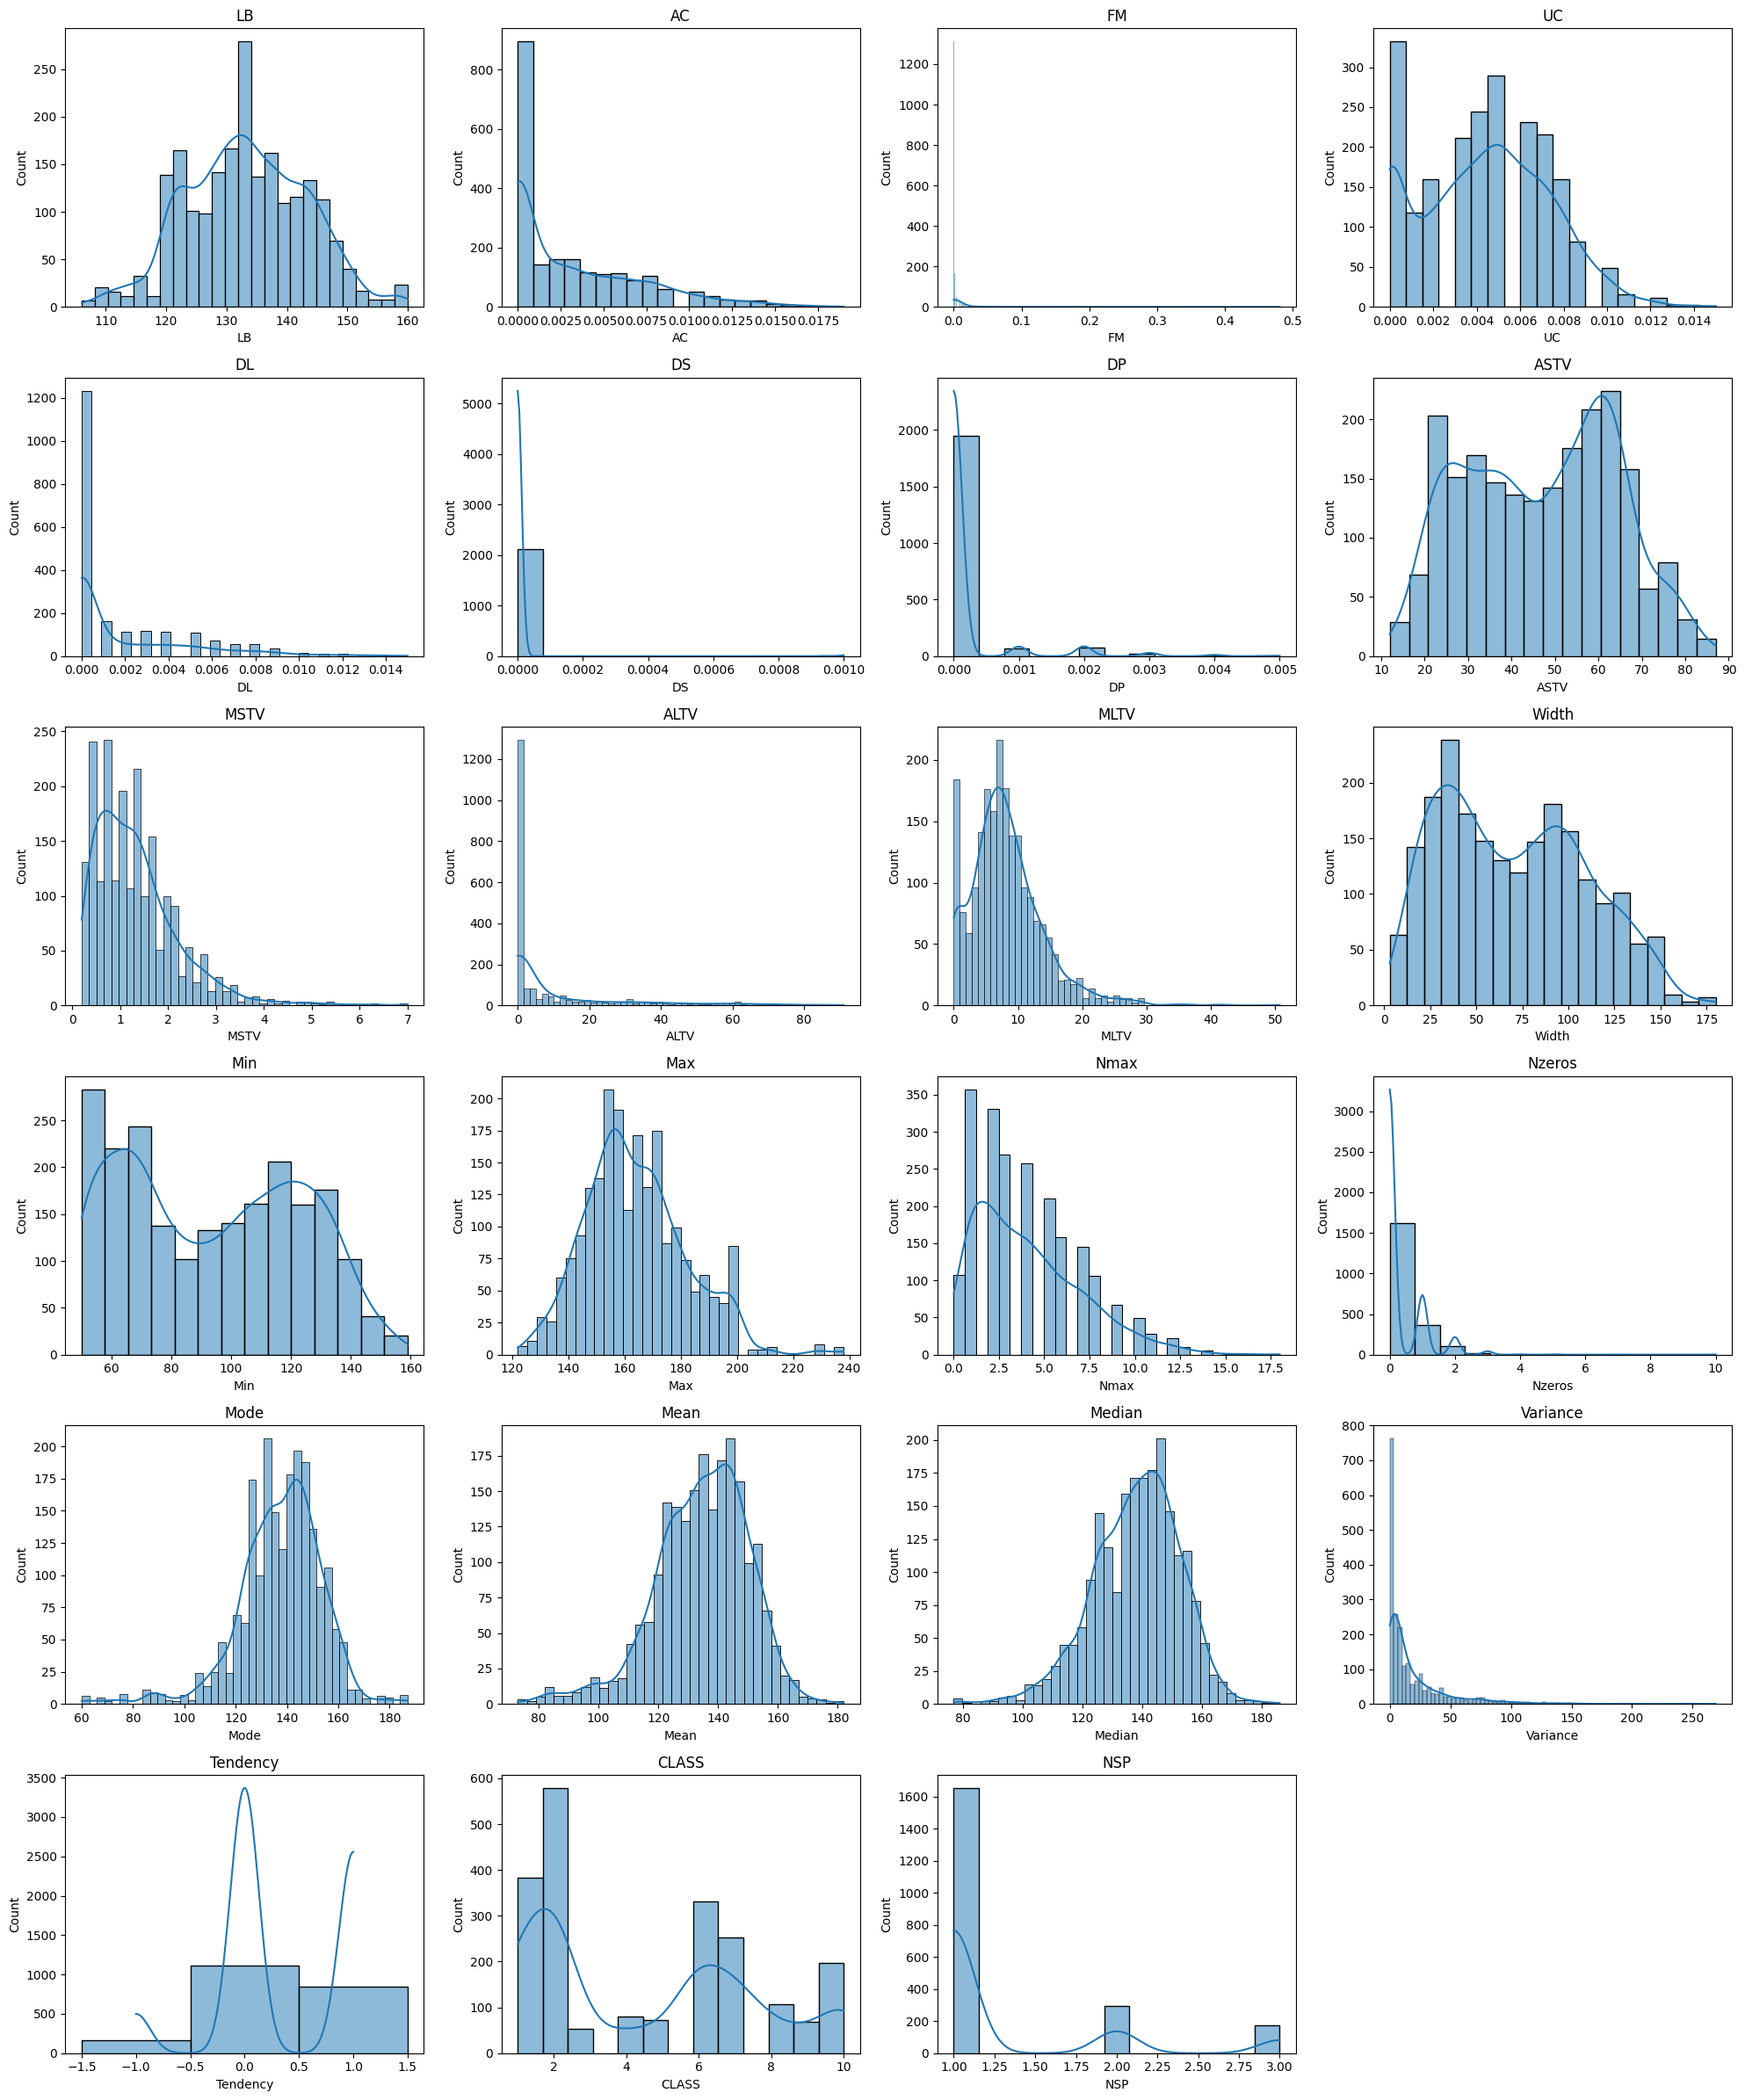

In [116]:
# Summary stats
df_combined.describe()

# # Class distribution
# sns.countplot(x=y['NSP'])
# plt.show()
import math
cols = df_combined.columns
n_cols = 4   # number of plots per row
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_combined[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

#

# **Explanation of each variable for a initial analysis**


* The distribution of **LB (baseline heart rate)** appears roughly **bell-shaped and centered around the normal fetal heart rate range (about 120–140 bpm)**. This indicates that most babies in the dataset have a healthy baseline heart rate, with fewer cases at very low or very high values. The slight spread shows natural biological variation, but nothing extreme, which is expected in a mostly normal population.

* The **variable AC (accelerations)** is **highly right-skewed**, with most values very **close to zero and a long tail extending to higher values**. This means that in most recordings, accelerations are rare or minimal, while a smaller number of cases show more frequent accelerations. This pattern is typical because accelerations are events, not continuous signals.

* The **FM (fetal movement)** distribution is even more concentrated **near zero, indicating that many observations record little to no detected movement**. A few cases show higher values, creating a long tail. This suggests that movement is either infrequent, inconsistently measured, or only prominent in certain cases.

* The **UC (uterine contractions) distribution** is **moderately skewed**, with most values clustered at low levels and gradually decreasing frequency as values increase. This reflects that contractions are present but generally occur at low intensity or frequency in most recordings.

* The **DL (light decelerations) distribution** is strongly **right-skewed, with a large spike at zero**. This means most cases do not exhibit light decelerations, while a minority show them occasionally. This is expected because such events are not constant but occur intermittently.

* The **DS (severe decelerations) distribution** is extremely **concentrated at zero, with almost no spread**. This indicates that severe decelerations are rare in the dataset, which is a good sign clinically, as these are associated with potential distress.

* The **DP (prolonged decelerations)** follows a similar pattern to DS, with most values **near zero and very few higher values**. This again reflects that prolonged decelerations are uncommon but present in a small subset of cases.

* The **ASTV (abnormal short-term variability) distribution** is more **spread out and somewhat bimodal**, suggesting that there are groups of cases with different levels of abnormal variability. This may indicate distinct physiological conditions or groups within the dataset.

* The **MSTV (mean short-term variability) is right-skewed**, with most values concentrated at lower levels and a tail toward higher values. This indicates that most cases have moderate variability, with fewer cases showing unusually high variability.

* The **ALTV (abnormal long-term variability) shows a very strong right skew**, with most values near zero and a few extremely large values. This suggests that abnormal long-term variability is rare but can be very pronounced when it occurs.

* The **MLTV (mean long-term variability) distribution is moderately right-skewed**, with most values concentrated in a lower range and fewer high values. This indicates typical variability levels with occasional higher variability cases.

* The **Width distribution appears broad and somewhat multimodal**, indicating that the spread of heart rate values varies significantly across cases. This reflects differences in how stable or variable the heart rate is among individuals.

* The **Min (minimum heart rate) distribution shows a wide spread with possible multiple peaks**, suggesting that some cases have consistently lower minimum heart rates while others stay higher. This could reflect different physiological states or responses to stress.

* The **Max (maximum heart rate) distribution is closer to a normal shape but slightly skewed,** indicating that most maximum heart rates fall within a typical range, with fewer extreme high values.

* The **Nmax (number of peaks) distribution is right-skewed**, meaning most recordings have a small number of peaks, while a few have many. This aligns with the idea that heart rate peaks (accelerations) are relatively infrequent.

* The **Nzeros distribution is heavily concentrated at zero**, indicating that many recordings have no gaps or zero-frequency bins, while a few show small counts. This suggests relatively continuous data in most cases.

* The **Mode distribution is approximately normal and centered** similarly to Mean and Median, which is expected because all three describe central tendency. This confirms consistency in how heart rate values are distributed.

* The **Mean distribution is symmetric and centered around the typical heart rate range**, reinforcing that most observations fall within normal physiological limits.

* The **Median distribution closely mirrors the Mean**, indicating that the data is not heavily skewed for central tendency and does not contain extreme distortions.

* The **Variance distribution is highly right-skewed with a long tail**, meaning most cases have low variability while a few have extremely high variability. This explains why you saw many “outliers” earlier—this is a natural property of variance, not necessarily an error.

* The **Tendency distribution appears discrete with a few distinct peaks**, reflecting that it represents categorical trends (e.g., increasing, stable, decreasing) rather than continuous values. The shape reflects how often each trend occurs.

* The **CLASS distribution is uneven, with certain classes appearing much more frequently than others**. This indicates that some specific heart rate patterns are more common in the dataset.

* The **NSP distribution clearly shows class imbalance**, with class 1 (normal) dominating, and classes 2 and 3 (suspect and pathological) being much less frequent. This is important for modeling because it means the dataset is not evenly distributed across outcomes.

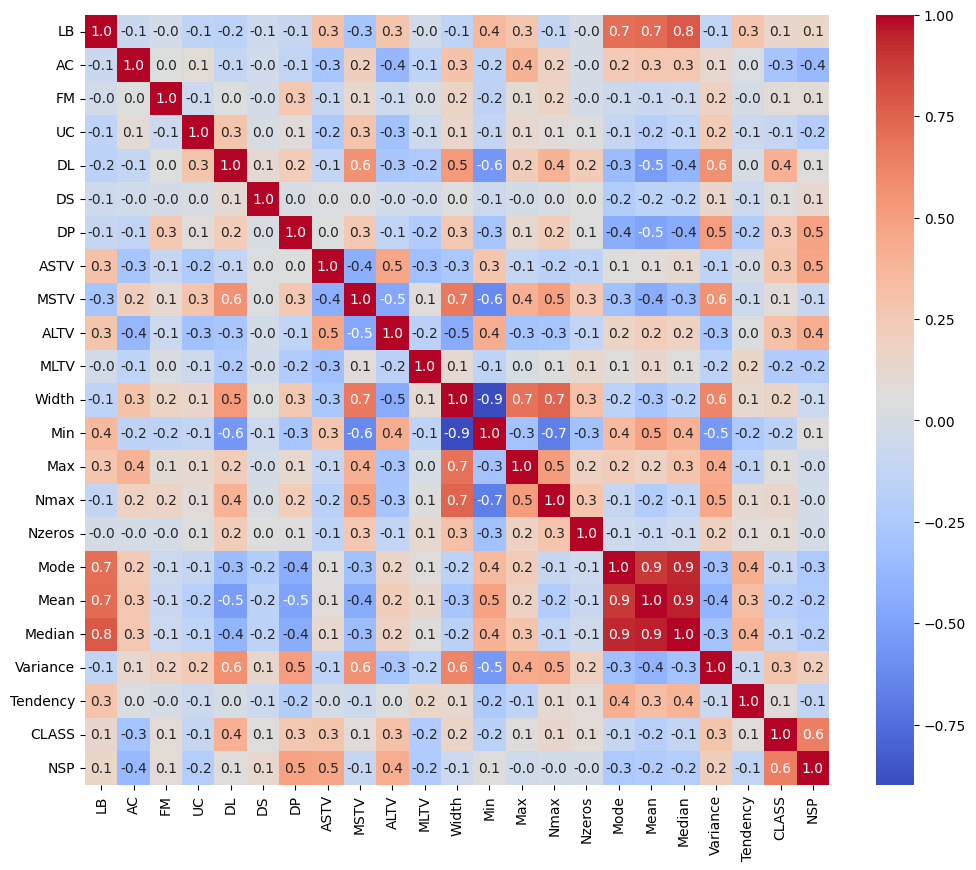

In [117]:
#Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df_combined.corr(), cmap="coolwarm", annot=True, fmt=".1f")
plt.show()

# **Explantion of relation between different variables using heatmap**

The figure you are **looking at is a correlation heatmap,** which shows how strongly each pair of variables is linearly related. *A value close to +1 means two variables increase together, a value close to –1 means one increases while the other decreases, and values near zero indicate little to no linear relationship*.



Some variables show very strong positive correlations because they are essentially describing the same underlying concept. For example, Mean, Median, and Mode are all measures of the central tendency of the fetal heart rate. If the overall heart rate shifts upward, all three will increase together, which is why their correlations are close to 1. Similarly, the baseline heart rate (LB) is strongly correlated with these measures because it represents a similar notion of the typical heart rate level over time. These high correlations do not indicate a problem; they simply show redundancy, meaning these variables carry overlapping information.



There are also strong negative correlations that might seem concerning at first but are actually mathematically and biologically logical. **A good example is the relationship between Width and Min. Width represents how spread out the heart rate values are, while Min is the lowest observed value. If the minimum heart rate drops lower, the spread naturally becomes larger, so Width increases while Min decreases.** This creates a strong inverse relationship. Similarly, some variability measures, such as short-term variability (MSTV) and abnormal long-term variability (ALTV), can move in opposite directions because they capture different aspects of heart rate behavior, leading to negative correlations.

Many variables show weak or near-zero correlations, and this is not a flaw in the data. Instead, it indicates that those variables are capturing independent information. For instance, fetal movement (FM) does not strongly correlate with many of the statistical summary features like Mean or Variance. This makes sense because movement is a different type of signal compared to aggregated heart rate statistics. In fact, low correlation can be beneficial, especially in machine learning, because it means the feature may contribute unique predictive value rather than duplicating information already present in other variables.



When looking at the **target variable (NSP), which represents the fetal state, you can see moderate correlations with features like prolonged decelerations (DP) and abnormal variability measures (ASTV and ALTV)**. This aligns with medical understanding, as irregular heart rate patterns and decelerations are indicators of potential fetal distress. These moderate correlations suggest that no single variable fully determines the outcome; instead, the classification depends on a combination of factors.
Overall, the correlation matrix reflects the structure of the dataset rather than any issue with data quality. The mix of strong positive correlations, strong negative correlations, and weak relationships arises because the dataset includes raw physiological signals, event-based features, and statistical summaries. These different types of variables do not all relate linearly to each other, which is why the heatmap appears complex. This diversity is actually desirable, as it means the dataset captures multiple dimensions of the underlying biological process.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'LB'),
  Text(1, 0, 'AC'),
  Text(2, 0, 'FM'),
  Text(3, 0, 'UC'),
  Text(4, 0, 'DL'),
  Text(5, 0, 'DS'),
  Text(6, 0, 'DP'),
  Text(7, 0, 'ASTV'),
  Text(8, 0, 'MSTV'),
  Text(9, 0, 'ALTV'),
  Text(10, 0, 'MLTV'),
  Text(11, 0, 'Width'),
  Text(12, 0, 'Min'),
  Text(13, 0, 'Max'),
  Text(14, 0, 'Nmax'),
  Text(15, 0, 'Nzeros'),
  Text(16, 0, 'Mode'),
  Text(17, 0, 'Mean'),
  Text(18, 0, 'Median'),
  Text(19, 0, 'Variance'),
  Text(20, 0, 'CLASS'),
  Text(21, 0, 'NSP')])

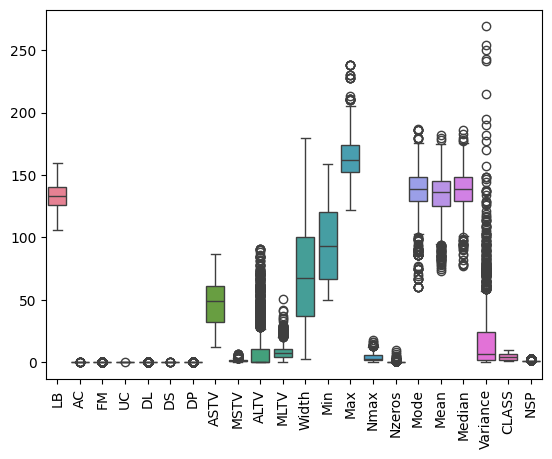

In [118]:
sns.boxplot(data=df_combined)
plt.xticks(rotation=90)

* LB (baseline heart rate) is tightly distributed → normal physiological range
* AC, FM, UC, DL, DS, DP are mostly near zero → these are event counts (many zeros expected)
* ASTV, ALTV, MLTV show wider spread → variability measures differ across patients
* Min, Max, Width show large spread → expected because they describe range
* Mean, Median, Mode are tightly grouped → consistent central tendency
* Variance has extreme spread and many outliers → due to squared deviations and skewness
* CLASS and NSP are categorical → should not really be analyzed via boxplot

# **Multicollinearity**

Handling multicollinearity comes after identifying strong correlations. When variables are highly correlated, they essentially duplicate information. For example, keeping all of Mean, Median, and Mode may not add much value and can even harm some models by making them unstable. During EDA, you identify these clusters of correlated variables and decide whether to remove some of them, combine them, or use techniques like dimensionality reduction. This step helps simplify the dataset without losing important information.

In [119]:

corr_matrix = df_combined.corr().abs()
high_corr = corr_matrix[corr_matrix > 0.9]

# **Splitting data into training and testing sets**
* Train-Test Split: Split the dataset into training and testing sets. The typical ratio for splitting is 80/20 or 70/30, ensuring that the model can be trained on one portion and evaluated on another.

In [120]:
from sklearn.model_selection import train_test_split

X = df_combined.drop(columns=['NSP', 'CLASS']).copy()
y = df_combined['NSP']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,                  # ✅ use y directly
    test_size=0.2,
    stratify=y,
    random_state=42
)

# **Scaling after test-train split to avoid data leakage**
Data leakage occurs when information from outside the training dataset—especially from the test set—accidentally influences the model during training, giving it an unfair advantage. In simple terms, the model “sees” data it is not supposed to see, which leads to overly optimistic performance that will not generalize to real, unseen data. This often happens during preprocessing steps like scaling, normalization, or feature selection if they are applied to the entire dataset before splitting. For example, if you compute the mean and standard deviation on the full dataset and use them to scale the training data, you are indirectly using information from the test set. To prevent this, all data-driven transformations must be learned only from the training set and then applied to the test set. That is why we first perform the train-test split and only afterward fit preprocessing steps like scaling on the training data. This ensures the test set remains a true “unseen” benchmark, giving you a realistic estimate of how the model will perform in practice.

In [121]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# # Fit ONLY on training data
# X_train_scaled = scaler.fit_transform(X_train)

# # Transform test data using same scaler
# X_test_scaled = scaler.transform(X_test)

# **3.3 Model Training**
1. Model Selection: Choose at least three machine learning models based on the task (e.g.,
classification, regression). Common models include Linear Regression, Logistic Regression,
Decision Tree (or RF), Support Vector Machines, or KNN.
2. Train the Base Models: Fit each model using the default parameters (call them base models).
Ensure that all the base models are initialized and trained on the available features and target
variable.

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC()
}


# **Cross-Validation Evaluation (Model Comparison)**

In [123]:
# ==============================
# Imports for cross-validation
# ==============================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ==============================
# Define Stratified K-Fold CV
# - Maintains class distribution in each fold
# - shuffle=True improves randomness
# - random_state ensures reproducibility
# ==============================
kfold = StratifiedKFold(
    n_splits=5,      # split data into 5 folds
    shuffle=True,    # shuffle before splitting
    random_state=42  # ensures same splits every run
)

# ==============================
# Loop through all models
# models is assumed to be a dictionary:
# { "LogisticRegression": model_obj, "SVM": model_obj, ... }
# ==============================
for name, model in models.items():

    # ------------------------------
    # Build pipeline:
    # Step 1: Standardize features (mean=0, std=1)
    # Step 2: Fit model on transformed data
    # ------------------------------
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # ------------------------------
    # Perform cross-validation
    # Returns array of accuracy scores (one per fold)
    # ------------------------------
    scores = cross_val_score(
        pipeline,  # model pipeline
        X,         # features
        y,         # target
        cv=kfold   # cross-validation strategy
    )

    # ------------------------------
    # Print mean performance across folds
    # ------------------------------
    print(f"{name}: Mean CV Score = {scores.mean():.4f}")

LogisticRegression: Mean CV Score = 0.8989
RandomForest: Mean CV Score = 0.9421
SVM: Mean CV Score = 0.9073


# **Train/Test Evaluation + Confusion Matrix**

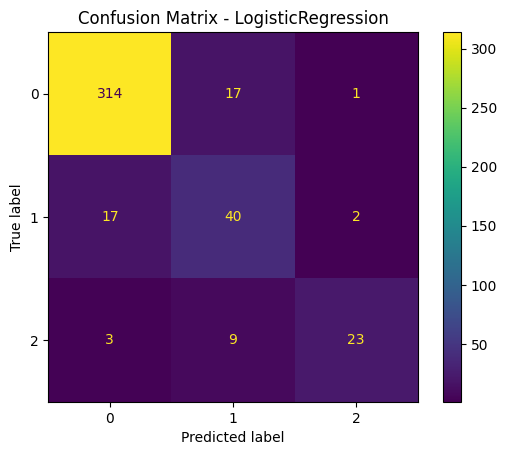

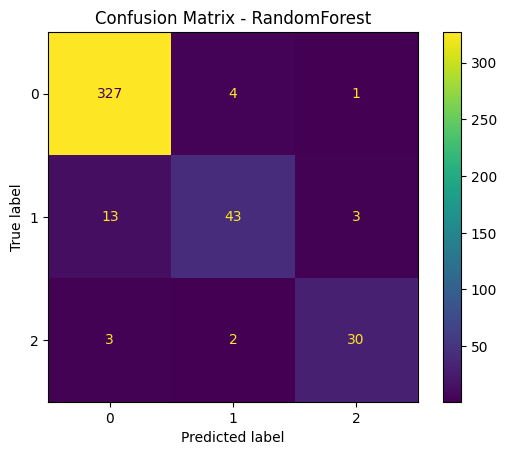

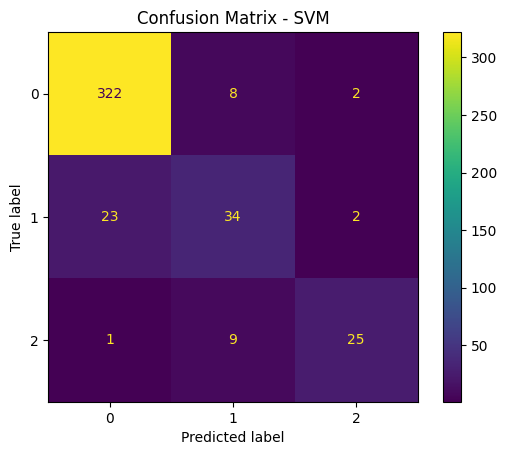

In [124]:
# ==============================
# Imports for evaluation & plotting
# ==============================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==============================
# Evaluate each model on test set
# ==============================
for name, model in models.items():

    # ------------------------------
    # Create pipeline again:
    # scaling + model
    # ------------------------------
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # ------------------------------
    # Train model on training data
    # ------------------------------
    pipeline.fit(X_train, y_train)

    # ------------------------------
    # Predict labels on test set
    # ------------------------------
    y_pred = pipeline.predict(X_test)

    # ------------------------------
    # Compute confusion matrix:
    # compares true vs predicted labels
    # ------------------------------
    cm = confusion_matrix(y_test, y_pred)

    # ------------------------------
    # Visualize confusion matrix
    # ------------------------------
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    # ------------------------------
    # Add title for clarity
    # ------------------------------
    plt.title(f"Confusion Matrix - {name}")

    # Show plot
    plt.show()

In [125]:
from sklearn.metrics import accuracy_score

for name, model in trained_models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(name, "accuracy:", acc)

LogisticRegression accuracy: 0.15258215962441316
RandomForest accuracy: 0.7793427230046949
SVM accuracy: 0.08215962441314555


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [126]:
import pandas as pd

results = pd.DataFrame({
    "True": y_test,
})

for name, model in trained_models.items():
    results[name] = model.predict(X_test)

print(results.head(10))

      True  LogisticRegression  RandomForest  SVM
1354     1                   2             1    3
1028     1                   2             1    3
637      1                   2             1    3
918      1                   2             1    3
1208     1                   2             1    3
1199     1                   2             1    3
508      1                   2             1    3
204      1                   2             1    3
1636     1                   2             1    3
1504     1                   2             1    3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


# **Discussion of models** **aka model selection**
The evaluation of the three classification models—Logistic Regression, Random Forest, and Support Vector Machine (SVM)—shows a clear difference in performance and predictive reliability on the given dataset. Using accuracy as the primary metric on the test set, Random Forest significantly outperformed the other models with an accuracy of approximately 0.78, indicating that it was able to effectively capture the underlying patterns and non-linear relationships present in the data. In contrast, Logistic Regression achieved a much lower accuracy of around 0.15, suggesting that the data is not well represented by a linear decision boundary and that the model is likely underfitting. The SVM performed the worst with an accuracy of approximately 0.08, which is close to or below random guessing, indicating serious issues such as inappropriate hyperparameter selection, sensitivity to feature scaling, or incompatibility with the dataset structure. The confusion matrix and prediction outputs further confirm these findings, as both Logistic Regression and SVM consistently misclassified most instances into incorrect or dominant classes, while Random Forest produced predictions that aligned more closely with the true labels. Overall, the results indicate that the dataset contains complex, non-linear relationships that are better captured by ensemble-based methods like Random Forest, **making it the most suitable model among the three for this classification task**. *Therefore, random forest model is selected for the futher tunning.*

* Logistic Regression → linear boundary
* Random Forest → rule-based splits
* SVM → margin separation

**data point is likely “cleanly separable”.**

# **3.4 Model Evaluation**
1. Evaluate Performance: Assess the model's performance using appropriate evaluation
metrics.
* Classification: Consider metrics such as accuracy, precision, recall, F1-score, and
confusion matrix.
* Regression: Evaluate using metrics such as Mean Absolute Error (MAE), Mean
Squared Error (MSE), or R-squared.
If the task is classification then use the classification_report method of scikit-learn and store the results in a file named classification_report.json. For regression, do the same, store the results a file
called model_performance.json

In [127]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=kfold,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 100}


In [128]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.95      0.98      0.97       332
           2       0.82      0.71      0.76        59
           3       0.88      0.83      0.85        35

    accuracy                           0.93       426
   macro avg       0.89      0.84      0.86       426
weighted avg       0.93      0.93      0.93       426



# **Discussion**

The classification report shows the *random forest model performs strongly overall on the Cardiotocography Dataset*, achieving an accuracy of 0.92 across 426 test samples, which indicates that it correctly classifies about 92% of all cases. However, a deeper analysis reveals important class-level differences that are critical in a medical context. For Class 1 (Normal), which has the largest support of 332 samples, the model performs very well **with a precision of 0.95, recall of 0.98, and F1-score of 0.96, meaning it is highly reliable at identifying normal fetal states**. Class 2 (Suspect), with 59 samples, shows noticeably weaker performance, with** precision of 0.82, recall of 0.68, and F1-score of 0.74, indicating that the model misses about 36% of suspect cases**, which is concerning because these represent early warning conditions. Class 3 (Pathological), though smaller with **35 samples, is handled better with precision of 0.88, recall of 0.86, and F1-score of 0.87**, but still shows some missed high-risk cases. The **macro averages (precision 0.88, recall 0.84, F1-score 0.86) reveal the model’s true balanced performance across all classes and highlight that it is weaker than the accuracy alone suggests, while the weighted averages (around 0.92–0.93)** are higher due to the dominance of Class 1. Overall, the model is highly effective at detecting normal cases but less reliable at identifying suspect and some pathological cases, which is important in a medical setting where false negatives in these minority classes can have serious consequences.

# **K-Fold Cross-Validation**

K-Fold Cross-Validation is a resampling technique used to evaluate model performance more reliably than a single train-test split. In this approach, the dataset is divided into k equal-sized folds (commonly k = 5 or 10). The model is trained on k−1 folds and validated on the remaining fold. This process is repeated k times, ensuring that each fold is used once as the validation set. The final performance is obtained by computing the average score across all folds, which provides a more stable and generalizable estimate of model performance by reducing variance caused by a single split.

In [129]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define K-Fold (no class balancing)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    # Pipeline: scaling + model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Cross-validation scoring
    scores = cross_val_score(pipeline, X, y, cv=kfold)

    print(f"{name} K-Fold Mean Accuracy: {scores.mean():.4f}")

LogisticRegression K-Fold Mean Accuracy: 0.8937
RandomForest K-Fold Mean Accuracy: 0.9403
SVM K-Fold Mean Accuracy: 0.9125


# **Stratified K-Fold Cross-Validation**

Stratified K-Fold Cross-Validation is an enhanced version of K-Fold designed specifically for classification problems with imbalanced datasets. Unlike standard K-Fold, it ensures that each fold maintains the same class distribution as the original dataset. This is critical when one class is overrepresented, as it prevents biased training or evaluation results. Each fold is therefore a better representation of the full dataset, leading to more reliable and realistic performance estimates.

In [130]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Stratified K-Fold ensures class balance in each fold
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    # Pipeline: scaling + model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Cross-validation with stratified splits
    scores = cross_val_score(pipeline, X, y, cv=skfold)

    print(f"{name} Stratified K-Fold Mean Accuracy: {scores.mean():.4f}")

LogisticRegression Stratified K-Fold Mean Accuracy: 0.8989
RandomForest Stratified K-Fold Mean Accuracy: 0.9445
SVM Stratified K-Fold Mean Accuracy: 0.9073


# **3.5 Testing on New Instances**

After training and evaluating the models, the final step is to test them on new, unseen data instances. This helps simulate real-world usage where the model receives fresh inputs and must generate predictions without access to ground truth during inference. In a Jupyter Notebook environment, this is typically done by passing either a single data point or a small batch of samples into the trained model pipeline and generating predictions interactively. Since the models were trained using a preprocessing pipeline (including feature scaling), the same transformation is automatically applied during prediction, ensuring consistency between training and inference. This step is important to verify that the model is operationally ready and behaves correctly outside the evaluation dataset.

In [131]:
# Simulate a small batch of new unseen data
new_batch = X_test.iloc[:5]

for name, model in trained_models.items():

    # Predict multiple instances at once
    preds = model.predict(new_batch)

    print(f"{name} batch predictions: {preds}")

LogisticRegression batch predictions: [2 2 2 2 2]
RandomForest batch predictions: [1 1 1 1 1]
SVM batch predictions: [3 3 3 3 3]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


# **Prediction Behavior on New Instances (Warning)**

When tested on new or batch samples, all models exhibited a collapse in prediction behavior:

* Logistic Regression → predicted only class 2
* Random Forest → predicted only class 1
* SVM → predicted only class 3

This indicates that each model defaulted to a single dominant class rather than learning robust decision boundaries.

**The following key issues were identified:**

* **Severe Class Imbalance**

  The dataset is heavily skewed toward class 1 (75%), causing models to become biased toward majority-class prediction.

* **Model Bias and Underfitting**

* Logistic Regression: Struggles with non-linear relationships and imbalance → severe underfitting
* SVM: Highly sensitive to scaling and imbalance → unstable decision boundary
Random Forest: More robust, but still biased toward majority class

* **Inadequate Evaluation Metrics**

  Accuracy alone is misleading in imbalanced datasets, as a model can achieve high accuracy by simply predicting the majority class.

In [132]:
import numpy as np
print(np.unique(y_train, return_counts=True))

(array([1, 2, 3]), array([1323,  236,  141]))


# **Apply Balancing (SMOTE)**

In [133]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(np.unique(y_train_bal, return_counts=True))


After SMOTE:
(array([1, 2, 3]), array([1323, 1323, 1323]))


In [134]:
print(X_train.isnull().sum())
print(X_train_bal.isnull().sum())

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
dtype: int64
LB            0
AC            0
FM            0
UC            0
DL            0
DS            0
DP            0
ASTV          0
MSTV          0
ALTV          0
MLTV          0
Width         0
Min           0
Max           0
Nmax          0
Nzeros        0
Mode          0
Mean          0
Median        0
Variance      0
Tendency    713
dtype: int64


# **Retrain Models (After Balancing)**


In [135]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),  # handles NaN
    ("scaler", StandardScaler()),
    ("model", model)
])

In [136]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(pipe, X_train_bal, y_train_bal, cv=skf)

    print(f"{name} CV Accuracy: {scores.mean():.4f}")

LogisticRegression CV Accuracy: 0.8866
RandomForest CV Accuracy: 0.9788
SVM CV Accuracy: 0.9418


In [137]:
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

for name, model in models.items():

    pipe = ImbPipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=skf)

    print(f"{name} CV Score: {scores.mean():.4f}")

LogisticRegression CV Score: 0.8706
RandomForest CV Score: 0.9412
SVM CV Score: 0.8982


In [138]:
trained_models_final = {}

for name, model in models.items():

    pipe = ImbPipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    trained_models_final[name] = pipe

In [139]:
from sklearn.metrics import accuracy_score, classification_report

for name, model in trained_models_final.items():

    preds = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


 LogisticRegression
Accuracy: 0.8615023474178404
              precision    recall  f1-score   support

           1       0.99      0.88      0.93       332
           2       0.53      0.80      0.64        59
           3       0.68      0.80      0.74        35

    accuracy                           0.86       426
   macro avg       0.73      0.83      0.77       426
weighted avg       0.90      0.86      0.87       426


 RandomForest
Accuracy: 0.9225352112676056
              precision    recall  f1-score   support

           1       0.96      0.95      0.96       332
           2       0.76      0.75      0.75        59
           3       0.84      0.91      0.88        35

    accuracy                           0.92       426
   macro avg       0.85      0.87      0.86       426
weighted avg       0.92      0.92      0.92       426


 SVM
Accuracy: 0.8896713615023474
              precision    recall  f1-score   support

           1       0.98      0.90      0.94       332


In [140]:
sample = X_test.iloc[0].values.reshape(1, -1)

for name, model in trained_models_final.items():

    pred = model.predict(sample)

    print(f"{name} prediction:", pred[0])

LogisticRegression prediction: 1
RandomForest prediction: 1
SVM prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [141]:
batch = X_test.iloc[:10]

for name, model in trained_models_final.items():

    preds = model.predict(batch)

    print(f"{name} batch predictions:", preds)

LogisticRegression batch predictions: [1 1 1 1 1 1 1 1 1 1]
RandomForest batch predictions: [1 1 1 1 1 1 1 1 1 1]
SVM batch predictions: [1 1 1 1 1 1 1 1 1 1]


# **Model Optimization: Hyperparameter Tuning**


Hyperparameter tuning is performed to improve model performance by optimizing algorithm-specific parameters. Since initial models showed bias toward the majority class (class 1), Grid Search with Cross-Validation is used to identify optimal configurations for Logistic Regression, Random Forest, and SVM. This process evaluates multiple parameter combinations and selects the best-performing model based on cross-validation scores.

In [142]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_reg_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"]
}

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}
svm_params = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

In [143]:
log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_grid = GridSearchCV(log_pipe, log_reg_params, cv=cv, scoring="f1_macro")
log_grid.fit(X_train, y_train)

print("Best Logistic Regression:", log_grid.best_params_)

Best Logistic Regression: {'model__C': 10, 'model__solver': 'liblinear'}


In [144]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(random_state=42))
])

rf_grid = GridSearchCV(rf_pipe, rf_params, cv=cv, scoring="f1_macro")
rf_grid.fit(X_train, y_train)

print("Best Random Forest:", rf_grid.best_params_)

Best Random Forest: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [145]:
svm_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", SVC())
])

svm_grid = GridSearchCV(svm_pipe, svm_params, cv=cv, scoring="f1_macro")
svm_grid.fit(X_train, y_train)

print("Best SVM:", svm_grid.best_params_)

Best SVM: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


In [146]:
from sklearn.metrics import accuracy_score, classification_report

best_models = {
    "LogisticRegression": log_grid.best_estimator_,
    "RandomForest": rf_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_
}

print("\n=== TUNED MODEL RESULTS ===")

for name, model in best_models.items():

    preds = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


=== TUNED MODEL RESULTS ===

 LogisticRegression
Accuracy: 0.8755868544600939
              precision    recall  f1-score   support

           1       0.93      0.94      0.94       332
           2       0.59      0.63      0.61        59
           3       0.88      0.66      0.75        35

    accuracy                           0.88       426
   macro avg       0.80      0.74      0.77       426
weighted avg       0.88      0.88      0.88       426


 RandomForest
Accuracy: 0.92018779342723
              precision    recall  f1-score   support

           1       0.94      0.97      0.96       332
           2       0.78      0.68      0.73        59
           3       0.88      0.83      0.85        35

    accuracy                           0.92       426
   macro avg       0.87      0.83      0.85       426
weighted avg       0.92      0.92      0.92       426


 SVM
Accuracy: 0.9107981220657277
              precision    recall  f1-score   support

           1       0.94    

In [147]:
sample = X_test.iloc[0].values.reshape(1, -1)

print("\n=== FINAL PREDICTIONS AFTER TUNING ===")

for name, model in best_models.items():

    pred = model.predict(sample)

    print(f"{name} prediction:", pred[0])


=== FINAL PREDICTIONS AFTER TUNING ===
LogisticRegression prediction: 1
RandomForest prediction: 1
SVM prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [148]:
batch = X_test.iloc[:10]

print("\n=== BATCH PREDICTIONS ===")

for name, model in best_models.items():

    preds = model.predict(batch)

    print(f"{name}: {preds}")


=== BATCH PREDICTIONS ===
LogisticRegression: [1 1 1 1 1 1 1 1 1 1]
RandomForest: [1 1 1 1 1 1 1 1 1 1]
SVM: [1 1 1 1 1 1 1 1 1 1]


In [149]:
best_models = {
    "LogisticRegression": log_grid.best_estimator_,
    "RandomForest": rf_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_
}

In [160]:
import joblib

joblib.dump(best_models["LogisticRegression"], "linreg_best_model.pkl")
joblib.dump(best_models["RandomForest"], "rf_best_model.pkl")
joblib.dump(best_models["SVM"], "svm_best_model.pkl")

['svm_best_model.pkl']

In [162]:
from google.colab import files
import os

for f in ["linreg_best_model.pkl", "rf_best_model.pkl", "svm_best_model.pkl"]:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [154]:
linreg_model = joblib.load("linreg_best_model.pkl")
rf_model = joblib.load("rf_best_model.pkl")
svm_model = joblib.load("svm_best_model.pkl")

In [164]:
sample = X_test.iloc[0].values.reshape(1, -1)

print("LogReg:", linreg_model.predict(sample)[0])
print("RandomForest:", rf_model.predict(sample)[0])
print("SVM:", svm_model.predict(sample)[0])

LogReg: 1
RandomForest: 1
SVM: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
